In [1]:
_ROOT_ = '../'

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.utils as vutils

import numpy as np
import matplotlib.pyplot as plt

import pytorch_lightning as pl
from PIL import Image

# Set random seed for reproducibility
manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  999


### Choose Your Training Device with `DEVICE_NAME`
CPU only: `'cpu'`, NVIDIA GPU:, `'cuda'`, Apple Silicon: `'mps'`

In [14]:
DEVICE_NAME = 'mps'
DEVICE = torch.device(DEVICE_NAME)

In [3]:
# Root directory for dataset
DATA_DIR = _ROOT_ + "./Data/CelebA"

# Batch size during training
BATCH_SIZE = 128

# Size of target images
IMG_SIZE = 32
# Number of channels in the training images. For color images this is 3
IMG_CHANNELS = 3

# dimension of z latent vector (i.e. dimension of generator input)
Z_DIM = 256
# dimension of the output of the encoder
ENC_DIM = 512

# Base number of feature maps
NUM_FT = 64

# Number of training epochs
EPOCHS = 10

# Learning rate for optimizers
LR = 0.0002
# Beta1 hyperparameter for the Adam optimizer
BETA = 0.5

In [4]:
class CelebA(torch.utils.data.Dataset):
    def __init__(self, img_paths, task):
        self.img_paths = img_paths
        self.imgtrans = self.get_transform(task)

    def load_img(self, img_path):
        img = Image.open(img_path)
        return img

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, index):
        img_path = self.img_paths[index]
        img = self.imgtrans(self.load_img(img_path))
        return img

    @staticmethod
    def get_transform(task, image_size=IMG_SIZE):
        if task == 'train':
            transform = transforms.Compose(
                    [
                        transforms.Resize((image_size, image_size)),
                        transforms.ToTensor(),
                        transforms.RandomHorizontalFlip(p=0.5),
                        transforms.Normalize(
                            [0.5 for _ in range(IMG_CHANNELS)],
                            [0.5 for _ in range(IMG_CHANNELS)],
                        ),
                    ]
                )
        else:
            transform = transforms.Compose(
                    [
                        transforms.Resize((image_size, image_size)),
                        transforms.ToTensor(),
                    ]
                )
        return transform

In [5]:
img_paths = os.listdir(DATA_DIR)
img_paths = [DATA_DIR + '/' + filename for filename in img_paths]

dataset = CelebA(img_paths, task='train')
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

### Variational Autoencoder
Varitiaonal Autoencoder (VAE) is an examplar of variational inference. The term "variational" comes from the calculus of variations, a field in math where people are interested in finding the maximum or minimum value of functions.

With VAE, our objective is to maximize the probability of observing the training data $p(x)$. We assume that the real data $x$ is dominated by some latent (unobservable) variable $z$. In VAE, we first try to model $p(z|x)$ with an encoder, then we reconstruct $x$ with a decoder by modeling $q(x|z)$. During trainig we enforce some known structures (Gaussians in most cases) on z. If we wish to generate some new samples with a VAE, we can simply sample from the known distribution and feed it to the decoder.

In [6]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        act_fn = nn.GELU
        self.network = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, NUM_FT, 3, 2, 1), # 32x32 => 16x16
            act_fn(),
            nn.Conv2d(NUM_FT, NUM_FT, 3, 1, 1),
            act_fn(),
            nn.Conv2d(NUM_FT, NUM_FT * 2, 3, 2, 1), # 16x16 => 8x8
            act_fn(),
            nn.Conv2d(NUM_FT * 2, NUM_FT * 2, 3, 1, 1),
            act_fn(),
            nn.Conv2d(NUM_FT * 2, NUM_FT * 4, 3, 2, 1), # 8x8 => 4x4
            act_fn(),
            nn.Conv2d(NUM_FT * 4, NUM_FT * 4, 3, 1, 1),
            act_fn(),
            nn.Conv2d(NUM_FT * 4, NUM_FT * 8, 4, 1, 0), # 4x4 => 1x1
            act_fn(),
            nn.Flatten(),
            nn.Linear(NUM_FT * 8, ENC_DIM)
        )

    def forward(self, x):
        return self.network(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        act_fn = nn.GELU
        self.linear = nn.Sequential(
            nn.Linear(Z_DIM, NUM_FT * 8),
            act_fn()
        )
        self.network = nn.Sequential(
            nn.ConvTranspose2d(NUM_FT * 8, NUM_FT * 8, 4, 1, 0), # 1x1 => 4x4
            act_fn(),
            nn.Conv2d(NUM_FT * 8, NUM_FT * 8, 3, 1, 1),
            act_fn(),
            nn.ConvTranspose2d(NUM_FT * 8, NUM_FT * 4, 3, 2, 1, output_padding=1), # 4x4 => 8x8
            act_fn(),
            nn.Conv2d(NUM_FT * 4, NUM_FT * 4, 3, 1, 1),
            act_fn(),
            nn.ConvTranspose2d(NUM_FT * 4, NUM_FT * 2, 3, 2, 1, 1), # 8x8 => 16x16
            act_fn(),
            nn.Conv2d(NUM_FT * 2, NUM_FT * 2, 3, 1, 1),
            act_fn(),
            nn.ConvTranspose2d(NUM_FT * 2, NUM_FT, 3, 2, 1, 1), # 16x16 => 32x32
            act_fn(),
            nn.Conv2d(NUM_FT, IMG_CHANNELS, 1, 1, 0),
            nn.Tanh() # The input images is scaled between -1 and 1, hence the output has to be bounded as well
        )

    def forward(self, x):
        x = self.linear(x)
        x = x.unsqueeze(-1).unsqueeze(-1)
        x = self.network(x)
        return x

### Testing `Encoder` and `Decoder`

In [7]:
tm = Encoder()
x = torch.randn(3, 3, 32, 32)
out = tm(x)
out.shape

torch.Size([3, 512])

In [8]:
tm = Decoder()
z = torch.randn(3, Z_DIM)
out = tm(z)
out.shape

torch.Size([3, 3, 32, 32])

### Intractable True Distribution

The biggest challenge with the above formulation is that it is impossible to estimate the true $p(z|x)$. This is because

\begin{align} p(z|x) = \frac{p(z)p(x|z)}{p(x)} = \frac{p(z)p(x|z)}{\int p(x|z)p(z)\, dz} \end{align}

When $z$ is high-demensional, the above integral is intractable because it is a multivaraite integral involving way too many variables shown below, where $z_i$ is the $i$-th dimension of $z$.
\begin{align} \int p(x|z)p(z)\, dz = \int ... \int p(z_1, z_2, ..., z_n)p(x|z_1, z_2, ..., z_n) \, dz_1 \, dz_2 \, ... dz_n \end{align}

In the [VAE paper](https://arxiv.org/abs/1312.6114), Welling et al. instead circumvent this problem by deriving a surrogate objective function.

### Training VAE by Maximizing Evidence Lower Bound (ELBO)
Recall that in maximum likelihood estimation, we wish to find a distribution that maximizes $\log p(x)$, where $x$ is the observed data. Let's start from here. By definition of a probability density function, we have $\int_z q(z|x) dz = 1$, then we have

\begin{align} \log p(x) = \log p(x) \int_z q(z|x) dz = \int_z q(z|x) \log p(x)dz \end{align}

Applying the Bayes theorem on $p(x)$, we have

\begin{align} \log p(x) = \int_z q(z|x) \log \frac{p(x, z)}{p(z|x)} dz = \int_z q(z|x) \log \frac{p(x, z)}{q(z|x)} \frac{q(z|x)}{p(z|x)} dz \end{align}

Then with the product property of logarithms,

\begin{align} \log p(x) = \int_z q(z|x) \log \frac{p(x, z)}{q(x|z)} dz + \int_z q(z|x) \log \frac{q(x|z)}{p(z|x)} dz \ge \int_z q(z|x) \log \frac{p(x, z)}{q(x|z)} dz \end{align}

The inequality above holds because the term $\int_z q(z|x) \frac{q(x|z)}{p(z|x)} dz$ is the KL divergence between q(z|x) and p(z|x) which is always non-negative.

The term $\int_z q(z|x) \log \frac{p(x, z)}{q(x|z)} dz$ is named the Evidence Lower Bound (ELBO). By raising this lower bound, we are also maximizing the probability of obersving the training data, hence ELBO is used as the loss function for VAE. Now we just need a few more steps of derivation on the ELBO.

\begin{align} \text{ELBO} = \int_z q(z|x) \log \frac{p(z)p(x|z)}{q(x|z)} dz = \int_z q(z|x)\log p(x|z) dz - \int_z q(z|x) \log \frac{q(z|x)}{p(z)} dz = \mathbb{E}_{z\sim q(z|x)}[\log p(x|z)] - \text{KL}(q(z|x)||p(z)) \end{align}

Maximizing ELBO is equivalent to minimizing the negative of it. Then our loss function becomes (KL - Expectation). The expecation term is called the reconstruction loss. This term tells us to first sample $z$ from $q(z|x)$, which is excatly the encoding process, namely given the input $x$ we derive its $z$. Then given the $z$ from the encoder, a natural way to maximize $p(x|z)$ is to just reconstruct the original input $x$ with the derived $z$, which is exactly the decoding process.

As for the KL divergence term, $p(z)$ is a known standard normal distribution. We want the encoder to try its best to yield Gaussian-like latent codes, namely we want $q(z|x)$ to be similar to a standard Gaussian.

In [9]:
class VAE(pl.LightningModule):
    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

        # distribution parameters
        self.fc_mu = nn.Linear(ENC_DIM, Z_DIM)
        self.fc_var = nn.Linear(ENC_DIM, Z_DIM)

        # for the gaussian likelihood
        self.log_scale = nn.Parameter(torch.Tensor([0.0]))

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4)

    def gaussian_likelihood(self, mean, logscale, sample):
        scale = torch.exp(logscale)
        dist = torch.distributions.Normal(mean, scale)
        log_pxz = dist.log_prob(sample)
        return log_pxz.sum(dim=(1, 2, 3))

    def kl_divergence(self, z, mu, std):
        # --------------------------
        # Monte carlo KL divergence
        # --------------------------
        # 1. define the first two probabilities (in this case Normal for both)
        p = torch.distributions.Normal(torch.zeros_like(mu), torch.ones_like(std))
        q = torch.distributions.Normal(mu, std)

        # 2. get the probabilities from the equation
        log_qzx = q.log_prob(z)
        log_pz = p.log_prob(z)

        # kl
        kl = (log_qzx - log_pz)
        kl = kl.sum(-1)
        return kl

    def training_step(self, batch, batch_idx):
        # encode x to get the mu and variance parameters
        x_encoded = self.encoder(batch)
        mu, log_var = self.fc_mu(x_encoded), self.fc_var(x_encoded)

        # sample z from q
        std = torch.exp(log_var / 2)
        q = torch.distributions.Normal(mu, std)
        z = q.rsample() # built-in reparameterization trick

        # decoded
        x_hat = vae.decoder(z)

        # reconstruction loss
        recon_loss = self.gaussian_likelihood(x_hat, self.log_scale, batch)

        # kl
        kl = self.kl_divergence(z, mu, std)

        # elbo
        elbo = (kl - recon_loss)
        elbo = elbo.mean()

        return elbo

In [10]:
def recon(vae, images):
    encoded = vae.encoder(images)
    mu = vae.fc_mu(encoded)
    x_hat = vae.decoder(z)

In [11]:
vae = VAE()
trainer = pl.Trainer(accelerator=DEVICE_NAME, devices=1, max_epochs=EPOCHS)
trainer.fit(vae, dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
C:\Python311\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:67: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA RTX A4000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_f

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=3` reached.


In [16]:
trainer.save_checkpoint("vae.ckpt")
print("Saved VAE to vae.pth")

Saved VAE to vae.pth


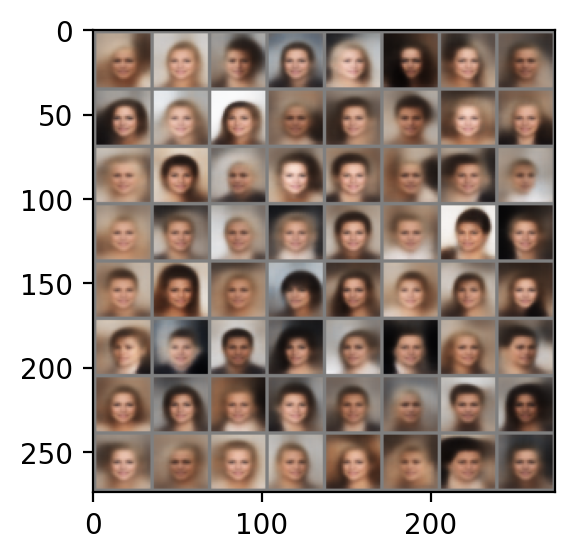

In [12]:
from matplotlib.pyplot import imshow, figure
import numpy as np
from torchvision.utils import make_grid
figure(figsize=(8, 3), dpi=200)

# Z COMES FROM NORMAL(0, 1)
num_preds = 64
p = torch.distributions.Normal(torch.zeros(Z_DIM), torch.ones(Z_DIM))
z = p.rsample((num_preds,))

# SAMPLE IMAGES
with torch.no_grad():
    pred = vae.decoder(z.to(vae.device)).cpu()

# UNDO DATA NORMALIZATION
mean, std = 0.5, 0.5
img = make_grid(pred).permute(1, 2, 0).numpy() * std + mean

# PLOT IMAGES
imshow(img);

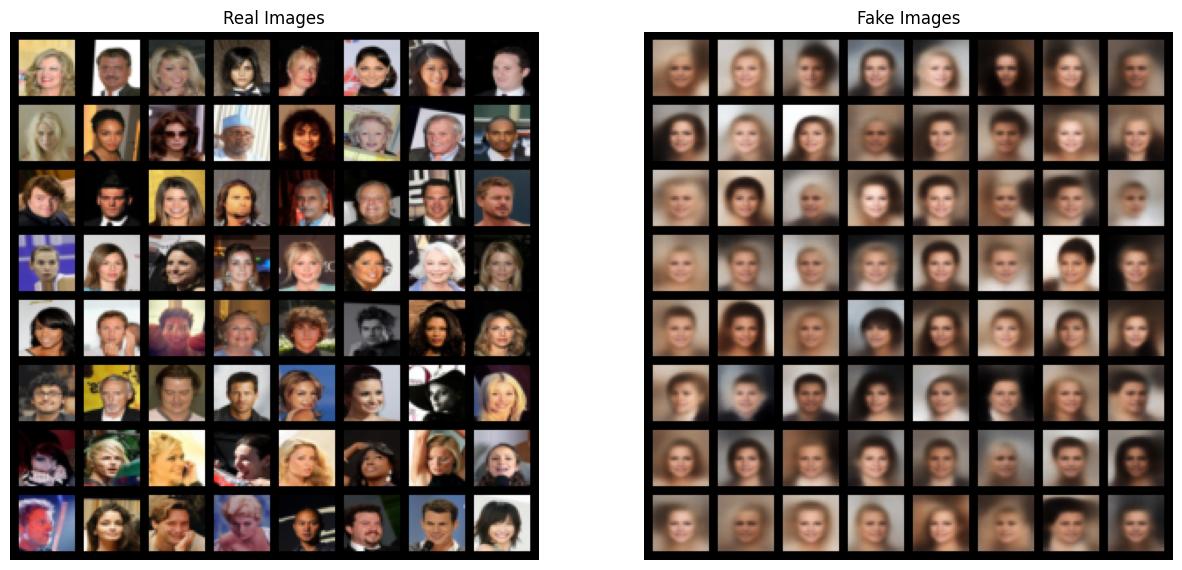

In [15]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch.to(DEVICE)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(vutils.make_grid(pred.to(DEVICE)[:64], padding=5, normalize=True).cpu(),(1,2,0)))
plt.show()

### Load a Pretrained Generator for Image Synthesis

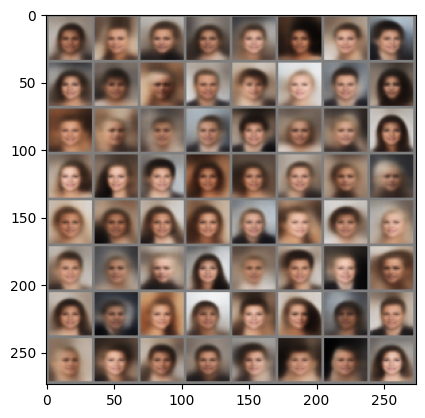

In [18]:
model = VAE.load_from_checkpoint(checkpoint_path= _ROOT_ + "./Model/vae.ckpt")

# Z COMES FROM NORMAL(0, 1)
num_preds = 64
p = torch.distributions.Normal(torch.zeros(Z_DIM), torch.ones(Z_DIM))
z = p.rsample((num_preds,))

# SAMPLE IMAGES
with torch.no_grad():
    pred = model.decoder(z.to(vae.device)).cpu()

# UNDO DATA NORMALIZATION
mean, std = 0.5, 0.5
img = make_grid(pred).permute(1, 2, 0).numpy() * std + mean

# PLOT IMAGES
imshow(img);